In [1]:
pip install keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import keras.models as km
from keras.models import Sequential
from keras import activations, initializers, regularizers, constraints
from keras.layers import Dense, Activation

In [2]:
import pandas as pd                                                 # Importing the libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn import tree
df = pd.read_excel(r"D:\DATA SCIENCE\numeric project\Hospital_Dataset.xlsx")   # Loading the dataset
df

,Age,Gender,Blood_Group,Height_cm,Weight_kg,Blood_Pressure,Heart_Rate,Oxygen_Level,Blood_Sugar,Temperature,...,Insurance_Type,Exercise_Level,Smoking_Status,Alcohol_Status,Diet_Type,Condition_Level,Hospital_Stay_Days,Treatment_Cost,Operation_Needed,Room_Allotted
0,26,Male,O+,189,117,190,105,89,191,39.0,...,Government,Low,Never,Not Available,Poor,Critical,9,389229,Yes,ICU
1,29,Female,B+,149,79,173,85,92,150,37.9,...,Not Available,High,Never,Moderate,Poor,Critical,21,585472,Yes,ICU
2,82,Male,AB+,179,45,120,120,92,167,37.5,...,Government,Low,Occasionally,High,Healthy,Mild,8,222382,Yes,Emergency Room
3,59,Male,O+,169,54,144,88,86,223,39.0,...,Not Available,Low,Occasionally,Moderate,Mixed,Critical,20,778900,Yes,ICU
4,38,Male,B-,164,108,113,81,95,217,39.8,...,Government,Low,Occasionally,High,Healthy,Critical,18,611002,Yes,ICU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,46,Male,A-,140,103,90,99,94,145,37.1,...,Not Available,High,Occasionally,Not Available,Healthy,Critical,14,563743,Yes,ICU
4996,72,Male,AB+,160,89,146,95,93,82,38.8,...,Not Available,Low,Never,Moderate,Healthy,Critical,11,460477,Yes,ICU
4997,35,Male,B+,157,56,115,105,89,167,36.3,...,Not Available,Low,Never,High,Healthy,Critical,13,412012,Yes,ICU
4998,78,Male,AB-,200,44,145,111,91,134,36.8,...,Not Available,Medium,Occasionally,Moderate,Poor,Critical,8,435563,Yes,ICU


### Data Information Gathering

In [3]:
df.info()   # Data Info Gathering Step 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Gender              5000 non-null   object 
 2   Blood_Group         5000 non-null   object 
 3   Height_cm           5000 non-null   int64  
 4   Weight_kg           5000 non-null   int64  
 5   Blood_Pressure      5000 non-null   int64  
 6   Heart_Rate          5000 non-null   int64  
 7   Oxygen_Level        5000 non-null   int64  
 8   Blood_Sugar         5000 non-null   int64  
 9   Temperature         5000 non-null   float64
 10  Cholesterol         5000 non-null   int64  
 11  Disease_Type        5000 non-null   object 
 12  Disease_Severity    5000 non-null   object 
 13  Previous_Disease    5000 non-null   object 
 14  Family_History      5000 non-null   object 
 15  Emergency_Case      5000 non-null   object 
 16  ICU_Re

In [4]:
df.head() # Data Info Gathering Step 2

,Age,Gender,Blood_Group,Height_cm,Weight_kg,Blood_Pressure,Heart_Rate,Oxygen_Level,Blood_Sugar,Temperature,...,Insurance_Type,Exercise_Level,Smoking_Status,Alcohol_Status,Diet_Type,Condition_Level,Hospital_Stay_Days,Treatment_Cost,Operation_Needed,Room_Allotted
0,26,Male,O+,189,117,190,105,89,191,39.0,...,Government,Low,Never,Not Available,Poor,Critical,9,389229,Yes,ICU
1,29,Female,B+,149,79,173,85,92,150,37.9,...,Not Available,High,Never,Moderate,Poor,Critical,21,585472,Yes,ICU
2,82,Male,AB+,179,45,120,120,92,167,37.5,...,Government,Low,Occasionally,High,Healthy,Mild,8,222382,Yes,Emergency Room
3,59,Male,O+,169,54,144,88,86,223,39.0,...,Not Available,Low,Occasionally,Moderate,Mixed,Critical,20,778900,Yes,ICU
4,38,Male,B-,164,108,113,81,95,217,39.8,...,Government,Low,Occasionally,High,Healthy,Critical,18,611002,Yes,ICU


In [5]:
df.tail()   # Data Info Gathering Step 3

,Age,Gender,Blood_Group,Height_cm,Weight_kg,Blood_Pressure,Heart_Rate,Oxygen_Level,Blood_Sugar,Temperature,...,Insurance_Type,Exercise_Level,Smoking_Status,Alcohol_Status,Diet_Type,Condition_Level,Hospital_Stay_Days,Treatment_Cost,Operation_Needed,Room_Allotted
4995,46,Male,A-,140,103,90,99,94,145,37.1,...,Not Available,High,Occasionally,Not Available,Healthy,Critical,14,563743,Yes,ICU
4996,72,Male,AB+,160,89,146,95,93,82,38.8,...,Not Available,Low,Never,Moderate,Healthy,Critical,11,460477,Yes,ICU
4997,35,Male,B+,157,56,115,105,89,167,36.3,...,Not Available,Low,Never,High,Healthy,Critical,13,412012,Yes,ICU
4998,78,Male,AB-,200,44,145,111,91,134,36.8,...,Not Available,Medium,Occasionally,Moderate,Poor,Critical,8,435563,Yes,ICU
4999,76,Female,A-,140,51,143,68,97,253,38.7,...,Private,High,Daily,Not Available,Healthy,Critical,19,458677,Yes,ICU


In [6]:
df.describe()  # Data Info Gathering Step 4

,Age,Height_cm,Weight_kg,Blood_Pressure,Heart_Rate,Oxygen_Level,Blood_Sugar,Temperature,Cholesterol,Medication_Count,Doctor_Visits,Hospital_Stay_Days,Treatment_Cost
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,53.925400,169.671000,80.290000,139.443000,92.976000,92.509000,164.875200,38.005900,209.715200,4.955400,7.505600,14.731600,5.428542e+05
std,21.281607,17.604532,23.382336,29.079647,21.712266,4.575031,55.297305,1.167042,52.811142,3.157563,4.614567,6.166131,1.871188e+05
min,18.000000,140.000000,40.000000,90.000000,55.000000,85.000000,70.000000,36.000000,120.000000,0.000000,0.000000,1.000000,2.506500e+04
25%,35.000000,154.000000,60.000000,114.000000,75.000000,89.000000,116.000000,37.000000,164.000000,2.000000,3.750000,9.000000,4.406422e+05
50%,54.000000,169.000000,81.000000,139.000000,93.000000,93.000000,164.000000,38.000000,208.000000,5.000000,7.500000,15.000000,5.482460e+05
75%,72.000000,185.000000,100.000000,164.000000,111.000000,96.000000,214.000000,39.000000,256.000000,8.000000,12.000000,20.000000,6.660948e+05
max,90.000000,200.000000,120.000000,190.000000,130.000000,100.000000,260.000000,40.000000,300.000000,10.000000,15.000000,25.000000,1.067095e+06


In [7]:
df.count()  # Data Info Gathering Step 5

Age                   5000
Gender                5000
Blood_Group           5000
Height_cm             5000
Weight_kg             5000
Blood_Pressure        5000
Heart_Rate            5000
Oxygen_Level          5000
Blood_Sugar           5000
Temperature           5000
Cholesterol           5000
Disease_Type          5000
Disease_Severity      5000
Previous_Disease      5000
Family_History        5000
Emergency_Case        5000
ICU_Required          5000
Medication_Count      5000
Doctor_Visits         5000
Insurance_Type        5000
Exercise_Level        5000
Smoking_Status        5000
Alcohol_Status        5000
Diet_Type             5000
Condition_Level       5000
Hospital_Stay_Days    5000
Treatment_Cost        5000
Operation_Needed      5000
Room_Allotted         5000
dtype: int64

Data Cleaning

In [8]:
df.duplicated().sum()   # Data Cleaning step 1

np.int64(0)

In [9]:
df.drop_duplicates()  

,Age,Gender,Blood_Group,Height_cm,Weight_kg,Blood_Pressure,Heart_Rate,Oxygen_Level,Blood_Sugar,Temperature,...,Insurance_Type,Exercise_Level,Smoking_Status,Alcohol_Status,Diet_Type,Condition_Level,Hospital_Stay_Days,Treatment_Cost,Operation_Needed,Room_Allotted
0,26,Male,O+,189,117,190,105,89,191,39.0,...,Government,Low,Never,Not Available,Poor,Critical,9,389229,Yes,ICU
1,29,Female,B+,149,79,173,85,92,150,37.9,...,Not Available,High,Never,Moderate,Poor,Critical,21,585472,Yes,ICU
2,82,Male,AB+,179,45,120,120,92,167,37.5,...,Government,Low,Occasionally,High,Healthy,Mild,8,222382,Yes,Emergency Room
3,59,Male,O+,169,54,144,88,86,223,39.0,...,Not Available,Low,Occasionally,Moderate,Mixed,Critical,20,778900,Yes,ICU
4,38,Male,B-,164,108,113,81,95,217,39.8,...,Government,Low,Occasionally,High,Healthy,Critical,18,611002,Yes,ICU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,46,Male,A-,140,103,90,99,94,145,37.1,...,Not Available,High,Occasionally,Not Available,Healthy,Critical,14,563743,Yes,ICU
4996,72,Male,AB+,160,89,146,95,93,82,38.8,...,Not Available,Low,Never,Moderate,Healthy,Critical,11,460477,Yes,ICU
4997,35,Male,B+,157,56,115,105,89,167,36.3,...,Not Available,Low,Never,High,Healthy,Critical,13,412012,Yes,ICU
4998,78,Male,AB-,200,44,145,111,91,134,36.8,...,Not Available,Medium,Occasionally,Moderate,Poor,Critical,8,435563,Yes,ICU


In [10]:
df.isnull().sum()    # Data Cleaning Step 2

Age                   0
Gender                0
Blood_Group           0
Height_cm             0
Weight_kg             0
Blood_Pressure        0
Heart_Rate            0
Oxygen_Level          0
Blood_Sugar           0
Temperature           0
Cholesterol           0
Disease_Type          0
Disease_Severity      0
Previous_Disease      0
Family_History        0
Emergency_Case        0
ICU_Required          0
Medication_Count      0
Doctor_Visits         0
Insurance_Type        0
Exercise_Level        0
Smoking_Status        0
Alcohol_Status        0
Diet_Type             0
Condition_Level       0
Hospital_Stay_Days    0
Treatment_Cost        0
Operation_Needed      0
Room_Allotted         0
dtype: int64

<Axes: xlabel='Disease_Type', ylabel='count'>

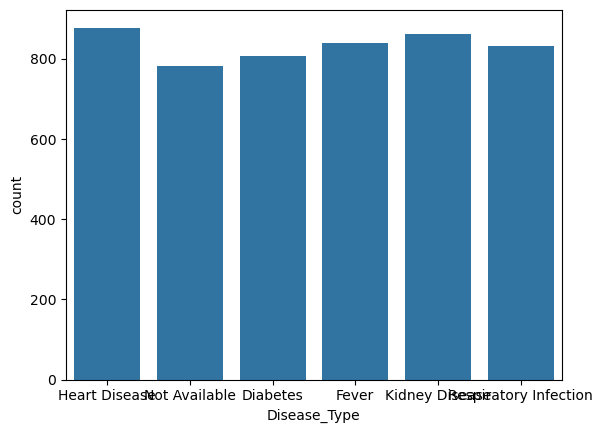

In [11]:
sns.countplot(x="Disease_Type",data=df)

<Axes: xlabel='Room_Allotted', ylabel='count'>

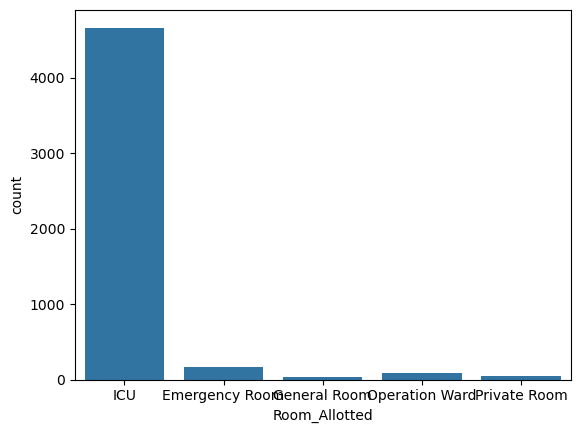

In [12]:
sns.countplot(x="Room_Allotted",data=df)

<Axes: xlabel='Hospital_Stay_Days', ylabel='Treatment_Cost'>

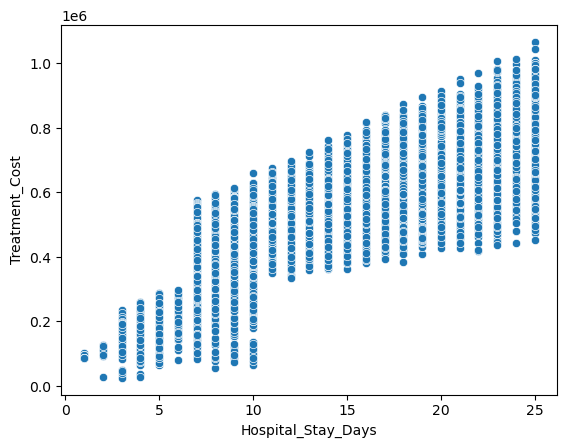

In [36]:
sns.scatterplot(x="Hospital_Stay_Days",y="Treatment_Cost",data=df)

<Axes: >

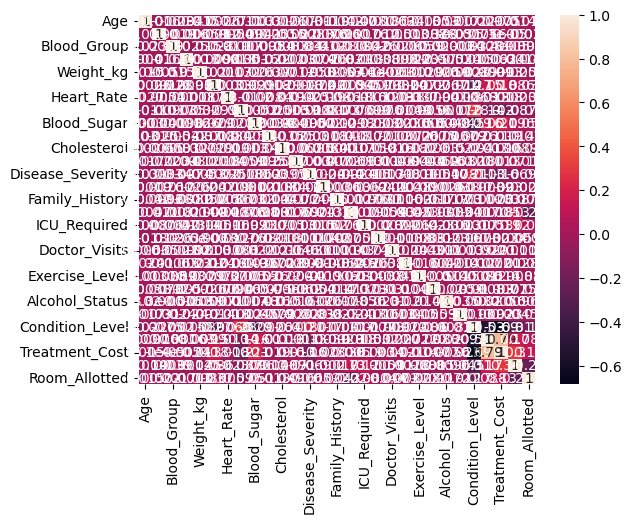

In [37]:
sns.heatmap(df.select_dtypes("number").corr(),annot=True)

In [15]:
le= LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Disease_Type"] = le.fit_transform(df["Disease_Type"])
df["Disease_Severity"] = le.fit_transform(df["Disease_Severity"])
df["Condition_Level"] = le.fit_transform(df["Condition_Level"])
df["Room_Allotted"] = le.fit_transform(df["Room_Allotted"])
df["Blood_Group"] = le.fit_transform(df["Blood_Group"])
df["Previous_Disease"] = le.fit_transform(df["Previous_Disease"])
df["Family_History"] = le.fit_transform(df["Family_History"])
df["Emergency_Case"] = le.fit_transform(df["Emergency_Case"])
df["ICU_Required"] = le.fit_transform(df["ICU_Required"])
df["Insurance_Type"] = le.fit_transform(df["Insurance_Type"])
df["Exercise_Level"] = le.fit_transform(df["Exercise_Level"])
df["Smoking_Status"] = le.fit_transform(df["Smoking_Status"])
df["Alcohol_Status"] = le.fit_transform(df["Alcohol_Status"])
df["Diet_Type"] = le.fit_transform(df["Diet_Type"])
df["Operation_Needed"] = le.fit_transform(df["Operation_Needed"])


In [38]:
X= df.drop("Treatment_Cost",axis=1)
y= df["Treatment_Cost"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [78]:
lr = LinearRegression()
lr.fit(X_train,y_train)
pred= lr.predict(X_test)
r2_l = r2_score(y_test,pred)
print(r2_l)

0.24599269629954346


In [79]:
dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)
pred = dt.predict(X_test)
r2_dt = r2_score(y_test,pred)
print(r2_dt)

1.0


In [80]:
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
pred = rf.predict(X_test)
r2_rf = r2_score(y_test,pred)
print(r2_rf)

0.989502538071066


In [81]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
svr = SVR(kernel="rbf",C=100,gamma="scale")
svr.fit(X_train,y_train)
pred = svr.predict(X_test)
r2_svr = r2_score(y_test,pred)
print("SVR R2 Score:",r2_svr)

SVR R2 Score: 0.6950569634248203


In [82]:
knn = KNeighborsRegressor()
knn.fit(X_train,y_train)
pred = knn.predict(X_test)
r2_knn = r2_score(y_test,pred)
print(r2_knn)

0.8104906937394247


In [84]:
reg_result = pd.DataFrame({"Model":["Linear Regression","Decision Tree","Random Forest","SVR","KNN"],"R2":[r2_l,r2_dt,r2_rf,r2_svr,r2_knn]})
reg_result.sort_values("R2",ascending=False)

,Model,R2
1,Decision Tree,1.000000
2,Random Forest,0.989503
4,KNN,0.810491
3,SVR,0.695057
0,Linear Regression,0.245993


In [47]:
X = df.drop(["Operation_Needed"],axis=1)
y =df["Operation_Needed"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [62]:
log = LogisticRegression()
log.fit(X_train,y_train)
pred=log.predict(X_test)
acc_log=accuracy_score(y_test,pred)
print(acc_log)

0.99


D:\GIRISH\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
dt =DecisionTreeClassifier()
dt.fit(X_train,y_train)
pred=dt.predict(X_test)
acc_dt=accuracy_score(y_test,pred)
print(acc_dt)

1.0


In [60]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
pred=rf.predict(X_test)
acc_rf=accuracy_score(y_test,pred)
print(acc_rf)

1.0


In [52]:
svc=SVC()
svc.fit(X_train,y_train)
pred=svc.predict(X_test)
acc=accuracy_score(y_test,pred)
print(acc)

0.986


In [63]:
knn =KNeighborsClassifier()
knn.fit(X_train,y_train)
pred =knn.predict(X_test)
acc_knn=accuracy_score(y_test,pred)
print(acc_knn)

0.988


In [64]:
clf_result=pd.DataFrame({"Model":["Logistic","Decision Tree","Random Forest","SVC","KNN"],"Accuracy":[acc_log,acc_dt,acc_rf,acc,acc_knn]})
clf_result.sort_values("Accuracy",ascending=False)

,Model,Accuracy
1,Decision Tree,1.000
2,Random Forest,1.000
0,Logistic,0.990
3,SVC,0.988
4,KNN,0.988


In [85]:
model = Sequential()

model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # regression output (Treatment Cost example)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1840 - mae: 0.2972
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0398 - mae: 0.1511
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0271 - mae: 0.1236
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0206 - mae: 0.1061
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0164 - mae: 0.0939
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0135 - mae: 0.0852
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0116 - mae: 0.0781
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0097 - mae: 0.0721
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084 - mae: 0.0667
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071 - mae: 0.0616
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 - mae: 0.0588
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057 - mae: 0.0555
Epoch 13/50
125/125 ━━━━━

In [86]:
ann_pred = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [88]:
acc=r2_score(y_test,ann_pred)
print(acc)

0.8923743367195129


# --- Clinical NLP Expansion Section ---
This section trains an NLP text classifier to parse unstructured, raw clinical reports / doctor notes and classify them into one of our 5 target disease categories: `Heart Disease`, `Diabetes`, `Fever`, `Kidney Disease`, or `Respiratory Infection`.

In [ ]:
# 1. Generate Synthetic Clinical Text Reports for Training
import pandas as pd
import random

diseases = ['Heart Disease', 'Diabetes', 'Fever', 'Kidney Disease', 'Respiratory Infection']
templates = {
    'Heart Disease': [
        "Patient presenting with acute chest pain radiating to left arm. Shortness of breath, tachycardia observed. ECG shows ST elevation, high blood pressure. Suspected myocardial infarction risk.",
        "ECG indicates cardiovascular instability. High cholesterol levels noted. Patient describes chest pressure, palpitations, and chronic fatigue. Heart rate is elevated.",
        "Cardiology report: Patient shows signs of coronary artery disease. History of hypertension, high lipid panel, and shortness of breath during exertion. Recommend angiography."
    ],
    'Diabetes': [
        "Routine endocrinology report: Patient presents with polyuria, polydipsia, and unexplained weight loss. Blood glucose level is extremely high. Monitoring HbA1c.",
        "Hyperglycemia observed. Elevated fasting blood sugar levels over 200 mg/dL. Chronic diabetes mellitus. Patient complaining of peripheral neuropathy and blurred vision.",
        "Endocrinologist note: Patient struggling with blood glucose control. High glucose levels. Suggesting Metformin and lifestyle modifications for type 2 diabetes management."
    ],
    'Fever': [
        "Acute febrile illness. Patient complains of high grade temperature, body aches, shivering, and severe headache. Vitals show hyperthermia. Recommend antipyretics.",
        "Influenza-like symptoms. Body temperature is 39.2 C. Chills, myalgia, and fatigue. Suspected viral fever. Administer Paracetamol and keep hydrated.",
        "Patient diagnosed with hyperthermia. High fever symptoms, throat congestion, body weakness. Vital signs show fever. Recommend bed rest and fluid intake."
    ],
    'Kidney Disease': [
        "Renal function impairment. Blood tests show elevated blood urea nitrogen (BUN) and serum creatinine. Decreased glomerular filtration rate (GFR). Suspected chronic kidney disease.",
        "Nephrology report: Patient has proteinuria and bilateral renal edema. Elevated creatinine. Diagnosed with renal insufficiency. Plan dialysis evaluation.",
        "Patient shows signs of kidney damage. Low urine output, chronic hypertension, elevated urea. Glomerular filtration compromised. Suggesting renal ultrasound."
    ],
    'Respiratory Infection': [
        "Pulmonary notes: Patient presents with productive cough, dyspnea, wheezing, and chest congestion. Oxygen saturation (SpO2) is low. Diagnosed with respiratory infection.",
        "Acute bronchitis symptoms. Productive phlegm, breathing difficulty, wheezing. Vitals reveal mild hypoxia. Suggest bronchodilators and antibiotics.",
        "Chest assessment: Bronchial breath sounds, cough, wheezing, fever, and dyspnea. Oxygen levels low at 91%. Diagnosed with acute respiratory tract infection."
    ]
}

# Generate 1000 synthetic records by mixing medical descriptors
data = []
for _ in range(1000):
    dis = random.choice(diseases)
    text = random.choice(templates[dis])
    # Add random age/vitals to reports to simulate real text report variations
    age = random.randint(20, 80)
    bp = random.randint(90, 180)
    hr = random.randint(60, 120)
    spo2 = random.randint(85, 99)
    sugar = random.randint(80, 280)
    temp = round(random.uniform(36.1, 40.0), 1)
    
    filler = f" Patient is a {age} y/o. Vitals show BP: {bp}/90, HR: {hr} bpm, SpO2: {spo2}%, Sugar: {sugar} mg/dL, Temp: {temp}C."
    full_text = text + filler
    data.append({"report_text": full_text, "disease_type": dis})

df_nlp = pd.DataFrame(data)
print("NLP Dataset Size:", df_nlp.shape)
df_nlp.head()


In [ ]:
# 2. Train and Save NLP Model (TF-IDF + Logistic Regression)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pickle

X_nlp = df_nlp['report_text']
y_nlp = df_nlp['disease_type']

X_train, X_test, y_train, y_test = train_test_split(X_nlp, y_nlp, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf_nlp = LogisticRegression(random_state=42)
clf_nlp.fit(X_train_vec, y_train)

y_pred = clf_nlp.predict(X_test_vec)
print(f"NLP Classifier Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Export NLP models to pickle
import os
models_dir = r"C:\Users\Girish Jindal\.geminintigravity\scratch\hospital_predict_ui\models"
os.makedirs(models_dir, exist_ok=True)

with open(os.path.join(models_dir, "nlp_vectorizer.pkl"), "wb") as f:
    pickle.dump(vectorizer, f)

with open(os.path.join(models_dir, "nlp_classifier.pkl"), "wb") as f:
    pickle.dump(clf_nlp, f)

print("NLP Pickle files exported to:", models_dir)
